In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay , classification_report, confusion_matrix, roc_auc_score, precision_recall_curve
from sklearn.model_selection import learning_curve, cross_val_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier



# setup colab server

In [2]:
!pwd

/content


In [2]:
!!git clone https://github.com/KenzyFrhat/Customer_Churn_Predictor

["fatal: destination path 'Customer_Churn_Predictor' already exists and is not an empty directory."]

In [4]:
%cd /content/Customer_Churn_Predictor

/content/Customer_Churn_Predictor


In [20]:
!git pull

remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (3/3), done.
Unpacking objects: 100% (4/4), 646 bytes | 646.00 KiB/s, done.
remote: Total 4 (delta 1), reused 4 (delta 1), pack-reused 0 (from 0)
From https://github.com/KenzyFrhat/Customer_Churn_Predictor
   ea82c3f..5e603f2  main       -> origin/main
Updating ea82c3f..5e603f2
Fast-forward
 src/{__pycache__ => }/predictor.py | 0
 1 file changed, 0 insertions(+), 0 deletions(-)
 rename src/{__pycache__ => }/predictor.py (100%)


In [7]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current directory:
/content/Customer_Churn_Predictor

Files:
['notebooks', 'src', '.git', 'README.md', 'Data', 'requirments']


In [26]:
!ls -R

.:
Customer_Churn_Predictor  Data	notebooks  README.md  requirments  src

./Customer_Churn_Predictor:
Data  notebooks  README.md  requirments  src

./Customer_Churn_Predictor/Data:
cleaned  ML_ready  Raw

./Customer_Churn_Predictor/Data/cleaned:
customer_churn_cleaned.csv

./Customer_Churn_Predictor/Data/ML_ready:
processor.pkl  X_test.pkl  X_train.pkl	y_test.pkl  y_train.pkl

./Customer_Churn_Predictor/Data/Raw:
WA_Fn-UseC_-Telco-Customer-Churn.csv

./Customer_Churn_Predictor/notebooks:
eda.ipynb

./Customer_Churn_Predictor/requirments:
requirements.txt

./Customer_Churn_Predictor/src:
feature_engineering.py	preprocessing.py

./Data:
cleaned  ML_ready  Raw

./Data/cleaned:
customer_churn_cleaned.csv

./Data/ML_ready:
processor.pkl  X_test.pkl  X_train.pkl	y_test.pkl  y_train.pkl

./Data/Raw:
WA_Fn-UseC_-Telco-Customer-Churn.csv

./notebooks:
eda.ipynb

./requirments:
requirements.txt

./src:
feature_engineering.py	preprocessing.py


In [35]:
!find . -name "*.pkl"

./predictors\best_et.pkl
./predictors\best_gb.pkl
./predictors\best_log.pkl
./Data/ML_ready/processor.pkl
./Data/ML_ready/X_test.pkl
./Data/ML_ready/X_train.pkl
./Data/ML_ready/y_train.pkl
./Data/ML_ready/y_test.pkl


# load data 

In [5]:
X_train = joblib.load(r"./Data/ML_ready/X_train.pkl")
X_test = joblib.load(r"./Data/ML_ready/X_test.pkl")
y_train = joblib.load(r"./Data/ML_ready/y_train.pkl")
y_test = joblib.load(r"./Data/ML_ready/y_test.pkl")
processor = joblib.load(r"./Data/ML_ready/processor.pkl")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid

# Modeling 

## Logistic Regression

In [6]:
log_clf = LogisticRegression(
    random_state=42,
    max_iter=1000, 
    C = 10,
    class_weight= 'balanced',
    l1_ratio = 1,
    solver =  'liblinear' 
    )

log_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


LogisticRegression(C=10, class_weight='balanced', l1_ratio=1, max_iter=1000,
                   random_state=42, solver='liblinear')

In [30]:
training_accuracy_score = accuracy_score(y_train, log_clf.predict(X_train))

log_y_pred = log_clf.predict(X_test)
accuracy = accuracy_score(y_test, log_y_pred)

print("Trianing accuracy score : ", training_accuracy_score)
print("Testing accuracy score :", accuracy)

Trianing accuracy score :  0.750534188034188
Testing accuracy score : 0.7395017793594306


In [31]:
print(classification_report(y_test, log_y_pred))

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1033
        True       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



In [32]:
def display_learning_curve(
    model, 
    X_train = X_train, 
    y_train = y_train, 
    cv = 5, 
    scoring = "f1", 
    inp_train_sizes = np.linspace(0.1, 1.0, 10), 
    random_state = 42,
    n_jobs = -1):

    train_sizes, train_scores, val_scores = learning_curve(
        model, 
        X_train, 
        y_train, 
        cv = cv, 
        train_sizes = inp_train_sizes, 
        random_state = random_state,
        scoring = scoring ,
        n_jobs = n_jobs
    
)

    train_mean = train_scores.mean(axis = 1)
    val_mean = val_scores.mean(axis = 1)

    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker='o', label='Training Score')
    plt.plot(train_sizes, val_mean, marker='o', label='Validation Score')

    plt.xlabel("Training Set Size")
    plt.ylabel("F1 score")
    plt.title(f"{type(model).__name__} Learning Curve")
    plt.legend()
    plt.grid(True)

    plt.show()



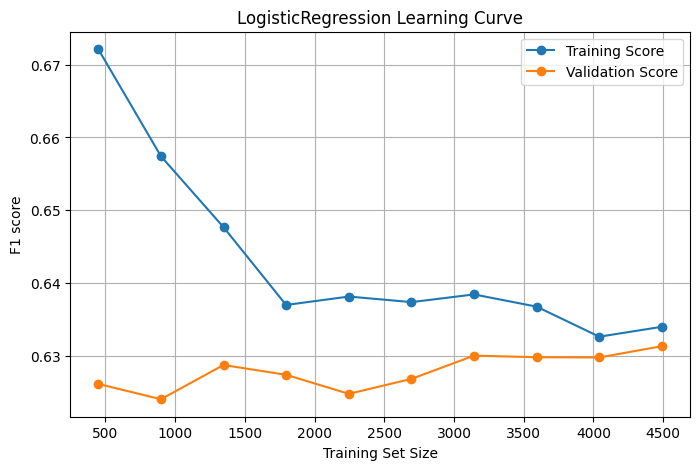

In [33]:
display_learning_curve(log_clf)


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"], 
    'class_weight' : [None, "balanced"]
}

grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1",      
    n_jobs=-1
)

grid.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'class_weight': [None, 'balanced'],
                         'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
             scoring='f1')

In [8]:
print("best params", grid.best_params_)
print(grid.best_score_)

best params {'C': 1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'liblinear'}
0.6324863345744738


In [9]:
best_log_clf = grid.best_estimator_
y_pred = best_log_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.73      0.80      1033
        True       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



In [37]:
from sklearn.metrics import make_scorer, f1_score

y_train_pred = best_log_clf.predict(X_train)
f1_score(y_train, y_train_pred)

0.6350288411116938

In [38]:
log_clf2 = LogisticRegression(
    max_iter = 1000, 
    C = 10,
    class_weight = "balanced", 
    penalty = 'l1', 
    solver = 'liblinear'
)

log_clf2.fit(X_train, y_train)

LogisticRegression(C=10, class_weight='balanced', max_iter=1000, penalty='l1',
                   solver='liblinear')

In [39]:
y_pred = log_clf2.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1033
        True       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405



In [ ]:
def display_thresholds(model):

    y_proba = model.predict_proba(X_test)[:, 1]

    precision, recall, thresholds = precision_recall_curve(
        y_test, 
        y_proba
    )

    log_f1 = 2 * (precision[:-1] * recall[:-1]) / (
        precision[:-1] + recall[:-1]
    )


    best_threshold_idx = np.argmax(log_f1)
    best_threshold_val = thresholds[best_threshold_idx]
    hightest_f1 = log_f1[best_threshold_idx]
    chosen_recall = recall[best_threshold_idx]
    chosen_precision = precision[best_threshold_idx]

    plt.figure(figsize=(12,6))

    plt.plot(
        thresholds,
        precision[:-1],
        label=f"Precision = {chosen_precision:.3f}"
    )

    plt.plot(
        thresholds,
        recall[:-1],
        label=f"Recall = {chosen_recall:.3f}"
    )

    plt.plot(
        thresholds,
        log_f1,
        label=f"Best F1 = {hightest_f1:.3f}" 

    )

    plt.axvline(
        x=best_threshold_val,
        color="red",
        linestyle="--",
        label=f"Best Threshold = {best_threshold_val:.3f}"
    )

    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.title(f"{type(model).__name__}\nPrecision, Recall, and F1 vs Threshold")
    plt.legend()
    plt.grid(True)

    plt.show()
    



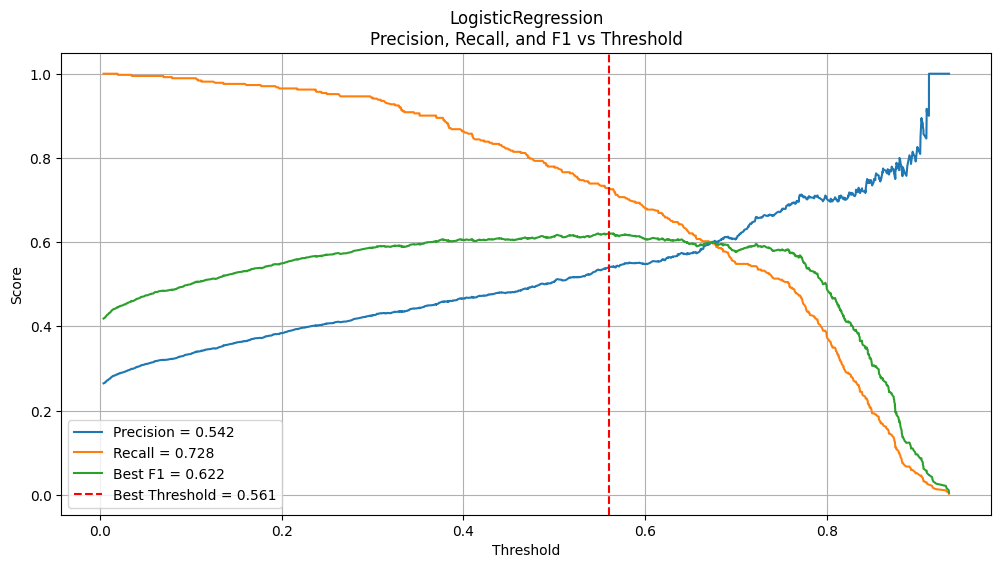

In [42]:
display_thresholds(best_log_clf)

In [10]:
best_log_clf_threshold = 0.561

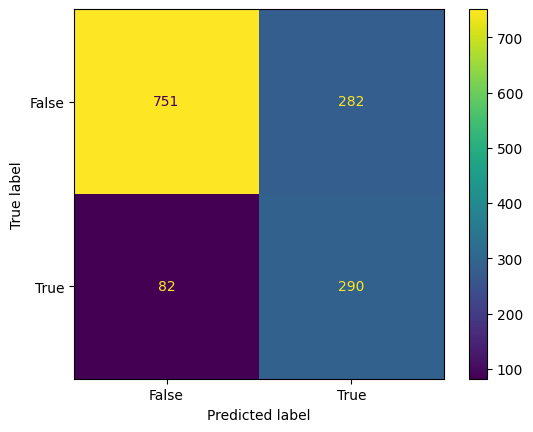

In [43]:
ConfusionMatrixDisplay.from_estimator(
    best_log_clf,
    X_test,
    y_test
)


## extra random forest

In [ ]:
et_clf = ExtraTreesClassifier(
    n_estimators=50,
    random_state=42,
    min_samples_leaf = 5,
    min_samples_split = 20,
    n_jobs=-1
)

et_clf.fit(X_train, y_train)
training_accuracy_score = accuracy_score(y_train, et_clf.predict(X_train))

et_y_pred = et_clf.predict(X_test)
accuracy = accuracy_score(y_test, et_y_pred)

print("Trianing accuracy score : ", training_accuracy_score)
print("Testing accuracy score :", accuracy)

Trianing accuracy score :  0.8466880341880342
Testing accuracy score : 0.7395017793594306


In [ ]:
print(classification_report(y_test, et_y_pred))
print(confusion_matrix(y_test, et_y_pred))

              precision    recall  f1-score   support

       False       0.90      0.72      0.80      1033
        True       0.51      0.78      0.61       372

    accuracy                           0.74      1405
   macro avg       0.70      0.75      0.71      1405
weighted avg       0.80      0.74      0.75      1405

[[748 285]
 [ 81 291]]


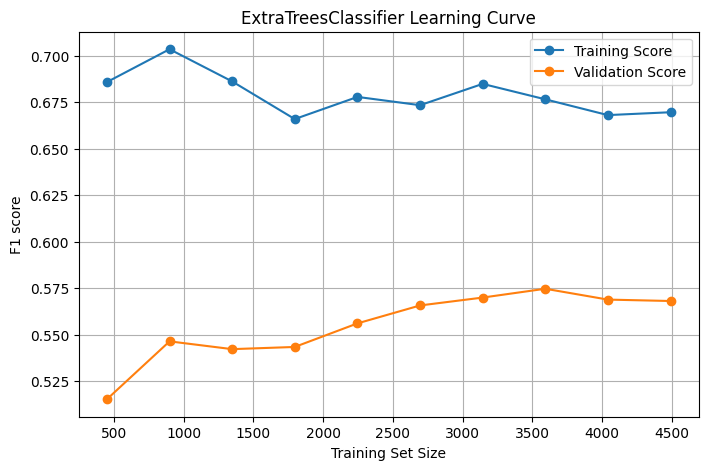

In [ ]:
display_learning_curve(et_clf)

In [ ]:
param_dist = {
    "n_estimators": [40, 50, 70, 100, 200, 300],
    "max_depth": [None, 5, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 5, 8],
    "max_features": ["sqrt", "log2", None],
    "class_weight": [None, "balanced"]
}

random_search = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=70,             
    scoring="f1",          
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 70 candidates, totalling 350 fits


RandomizedSearchCV(cv=5, estimator=ExtraTreesClassifier(random_state=42),
                   n_iter=70, n_jobs=-1,
                   param_distributions={'class_weight': [None, 'balanced'],
                                        'max_depth': [None, 5, 10, 20, 30, 50],
                                        'max_features': ['sqrt', 'log2', None],
                                        'min_samples_leaf': [1, 2, 4, 5, 8],
                                        'min_samples_split': [2, 5, 10, 20],
                                        'n_estimators': [40, 50, 70, 100, 200,
                                                         300]},
                   random_state=42, scoring='f1', verbose=1)

In [ ]:
best_et_clf = random_search.best_estimator_
print(random_search.best_params_)
print("best F1 score: ", random_search.best_score_)

{'n_estimators': 40, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': 'balanced'}
best F1 score:  0.6298854594988708


In [ ]:
et_pred = best_et_clf.predict(X_test)
print(classification_report(y_test, et_pred))

              precision    recall  f1-score   support

       False       0.89      0.76      0.82      1033
        True       0.53      0.74      0.62       372

    accuracy                           0.76      1405
   macro avg       0.71      0.75      0.72      1405
weighted avg       0.79      0.76      0.77      1405



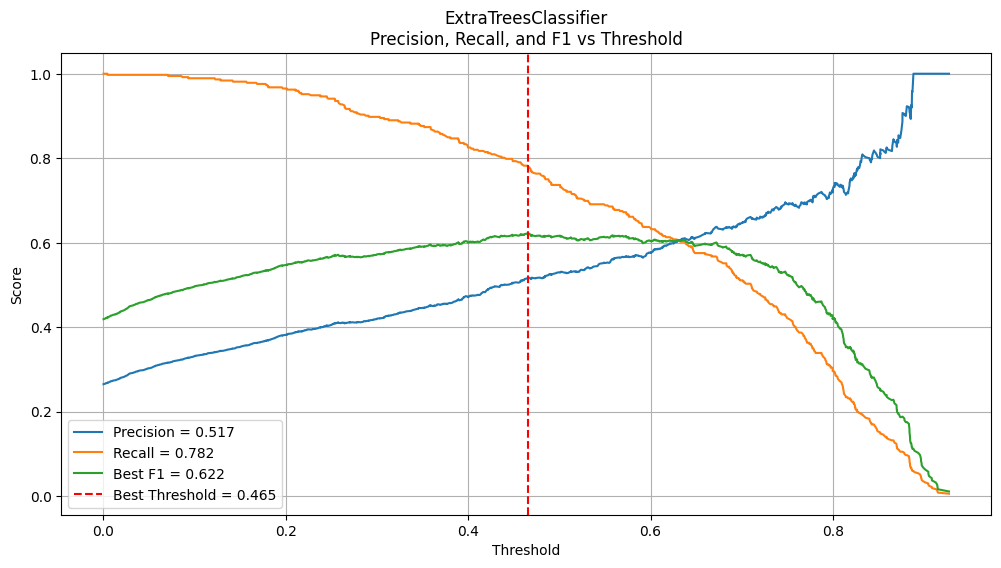

In [ ]:
display_thresholds(et_clf)

In [13]:
et_clf_threshold = 0.465

## Gradient Boosting 

In [ ]:


gb_clf = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_clf.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

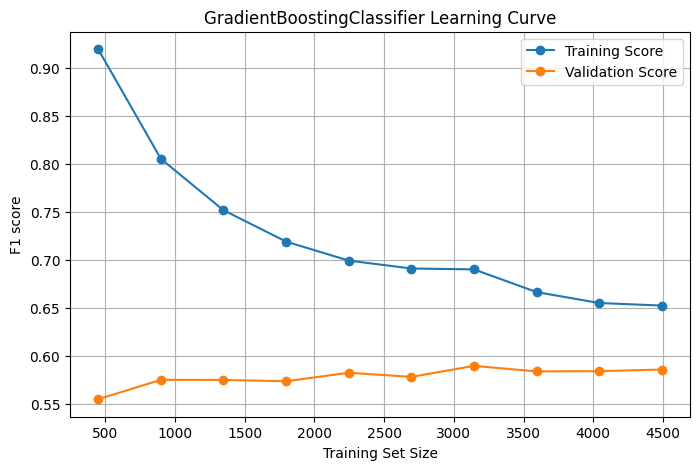

In [ ]:
display_learning_curve(gb_clf)

In [53]:
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500, 350, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 10],
    "subsample": [0.8, 0.9, 1.0]
}


random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=100,             
    scoring="f1",          
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


: 

In [ ]:
best_gb_clf = random_search.best_estimator_
print(random_search.best_params_)
print("best F1 score: ", random_search.best_score_)

{'subsample': 0.8, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.05}
best F1 score:  0.5923469695723582


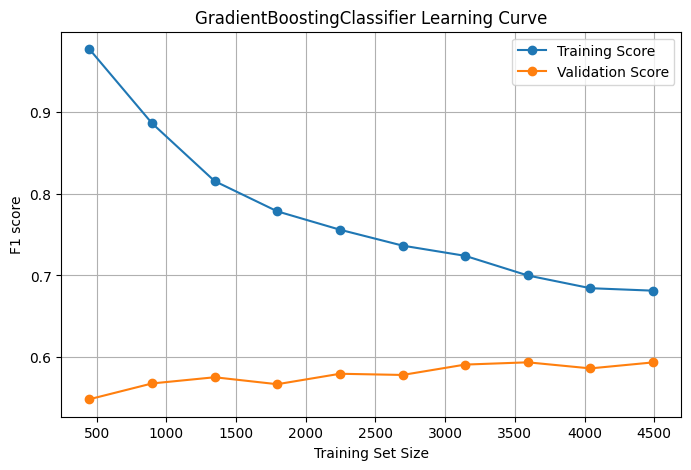

In [ ]:
display_learning_curve(gb_clf)

In [ ]:
gb_clf_pred = gb_clf.predict(X_test)
print(classification_report(y_test, gb_clf_pred))

              precision    recall  f1-score   support

       False       0.84      0.91      0.87      1033
        True       0.66      0.51      0.57       372

    accuracy                           0.80      1405
   macro avg       0.75      0.71      0.72      1405
weighted avg       0.79      0.80      0.79      1405



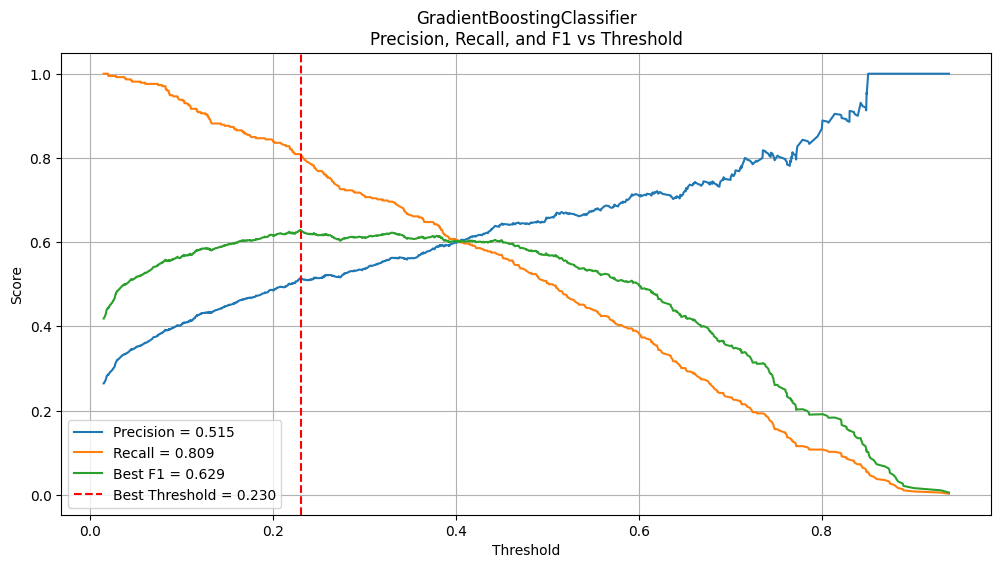

In [ ]:
display_thresholds(gb_clf)

In [15]:
best_gb_clf_threshold = 0.230

# saving models 

In [16]:
from src.predictor import ChurnModel

log_predictor = ChurnModel(best_log_clf, best_log_clf_threshold)
et_predictor = ChurnModel(et_clf, et_clf_threshold)
gb_predictor = ChurnModel(best_gb_clf, best_gb_clf_threshold)

joblib.dump(log_predictor, r".\predictors\best_log.pkl" )
joblib.dump(et_predictor, r".\predictors\best_et.pkl")
joblib.dump(gb_predictor, r".\predictors\best_gb.pkl")

['.\\predictors\\best_gb.pkl']